In [1]:
import em_utils.mt_simple as mt
import matplotlib.pyplot as plt
import numpy as np
import datetime
from scipy.constants import mu_0

import importlib
import json

# Lab EM5 - MT Data Processing

Due: Noon 2/14/2025s

Objectives:
* Perform the basic operations involved in MT processing
* Obtain transfer functions from time-series data
* See how the transfer function changes with each of the processing steps


## IRIS
The IRIS database contains pre-processed transfer functions for many MT sites throughout the world!

Our goal is to use simple processing steps to see if we can get close to one of them.

[transfer functions](https://ds.iris.edu/spud/emtf)

## Tiny Town!

The first data set is from Tiny Town, Colorado. It has been cultivated a bit already from the raw time-series data, and the `json` file includes all necessary details about the survey details needed to process the time-series into transfer functions (channel calibration filters, orientations, sample rates, start times, etc.)

In [3]:
cop = mt.MTTimeChannelCollection.from_json("data/Lab5/cop24.json")

## Plotting channels

The first thing done is usually to plot the raw channel data to look for any obvious issues in the time-series data.

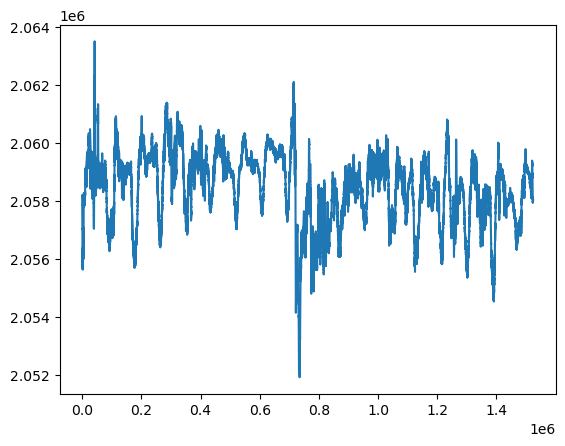

In [45]:
cop.channels[2].plot()

### Transfer functions

You can calculate transfer functions between the different channels using just the raw data, but they don't really mean anything, and are usually very very noisy.

Steps:
* First convert to a frequency spectrum (uses a fast-fourier transform)
* Then calculate the transfer functions and plot apparent resistivity as a function of period

In [46]:
COP = cop.frequency_spectrum()

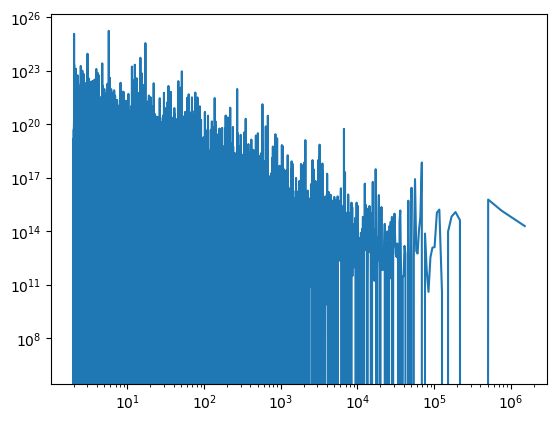

In [47]:
f, Z = COP.calculate_transfer_funcs()
rho_a = mt.calc_rho_a(f, Z)
plt.loglog(1/f, rho_a[..., 0, 1])

## Calibrating the data

The raw data are in units of a Recorded Voltage. These channels have often been
* Gained
* Low-pass filtered
* High-pass filtered
* Recorded by a sensor that does not have a flat frequency response.

We need to undo these operations to get data in the expected units (V/m for Electric Field, and A/m for the Magnetic Field).

* Undoing these operations amount to a deconvolution!

In [58]:
# The recorded electric field V has been gained by:
# 100 m (the dipole length), and 409600000.0 by the internal electronics.
cop.channels[0].gain

[100, 409600000.0]

In [59]:
# it has also been low pass (and high pass) filtered
cop.channels[0].zpk_filter

[{'p': [(-3.883009+11.951875j),
   (-3.883009-11.951875j),
   (-10.166194+7.386513j),
   (-10.166194-7.386513j),
   (-12.566371+0j)],
  'z': [],
  'k': 313383.493219835},
 {'p': [-0.000167], 'z': [0.0], 'k': 1.00000000378188}]

In [60]:
COP = cop.frequency_spectrum().calibrate()

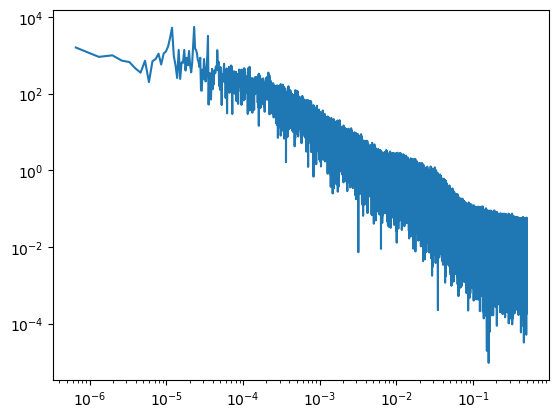

In [62]:
ch = COP.channels[3]
ch.plot()

Again calculate the transfer functions. They are still very noisy, but they are at least on the correct units.

In [65]:
f, Z = mt.calculate_Z(COP)
rho_a = mt.calc_rho_a(f, Z)

Text(0, 0.5, '$\\rho_a$ $(\\Omega m)$')

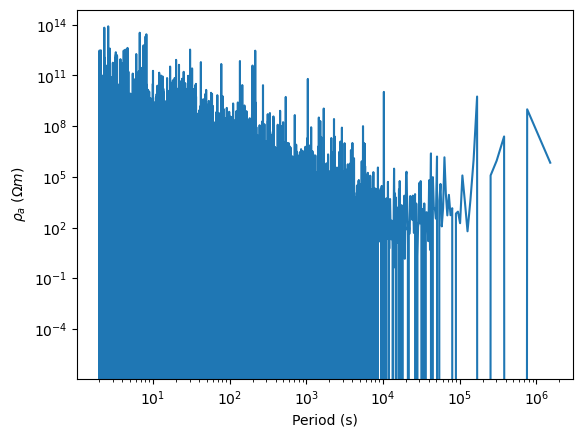

In [66]:
plt.loglog(1/f, rho_a[..., 0, 1])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")

## splitting data

One method of reducing noise it to split the time-series data into multiple runs, and then average them together to compute the transfer functions.

In [67]:
n_splits = 50

In [68]:
cop_split = cop.split(n_splits)
COP_split = cop_split.frequency_spectrum().calibrate()

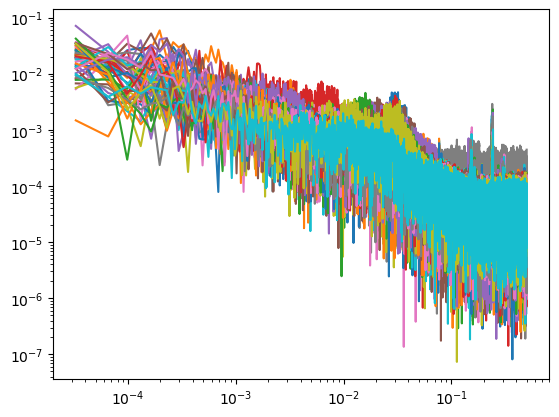

In [69]:
COP_split.channels[0].plot()

In [70]:
f, Z = mt.calculate_Z(COP_split)
rho_a = mt.calc_rho_a(f, Z)

Text(0, 0.5, '$\\rho_a$ $(\\Omega m)$')

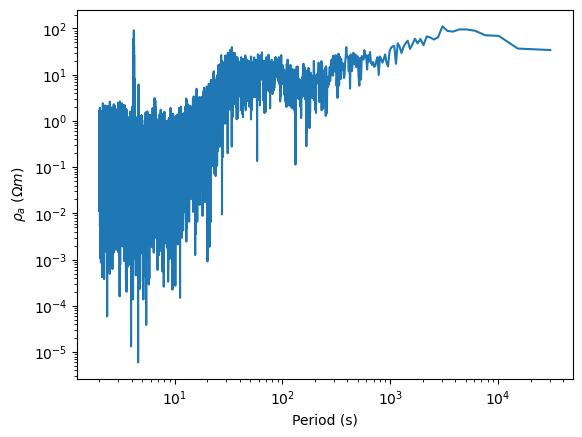

In [71]:
plt.loglog(1/f, rho_a[..., 0, 1])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")

## Windowing!

Observing a dataset for a specific amount of time is equivalent to applying a box-car to time-series data. Applying sharp cutoffs in one domain (time here) usually causes ringing in the other domain (frequency). We can reduce this by windowing the data using a smoother function than the box-car. Hammer windows are a common choice in MT (which is what is done here).

In [72]:
cop_wind = cop_split.window()
COP_wind = cop_wind.frequency_spectrum().calibrate()

In [73]:
f, Z = mt.calculate_Z(COP_wind)
rho_a = mt.calc_rho_a(f, Z)

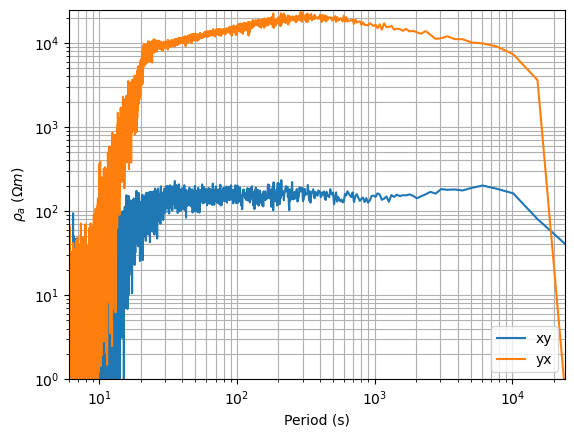

In [74]:
plt.loglog(1/f, rho_a[..., 0, 1], label='xy')
plt.loglog(1/f, rho_a[..., 1, 0], label='yx')
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Orienting

This data was not collected oriented with geographic North. The voltage dipoles were collected at a significant angle to North, and the magnetometers were aligned with magnetic North.

For comparison with many stations, we often want to re-orient our survey to align with geographic North (by rotating the channel pairs).

In [78]:
COP_wind.channels[0].azimuth * 180/np.pi

334.3

In [79]:
COP_orient = COP_wind.orient()

In [80]:
f, Z = mt.calculate_Z(COP_orient)
rho_a = mt.calc_rho_a(f, Z)

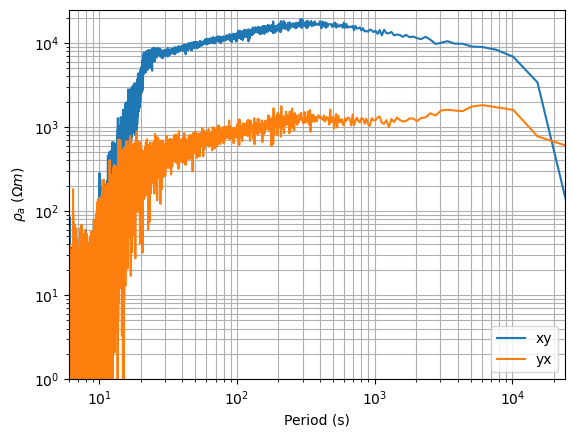

In [81]:
plt.loglog(1/f, rho_a[..., 0, 1], label='xy')
plt.loglog(1/f, rho_a[..., 1, 0], label='yx')
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Detrend

Detrending the time-series (removing a best fit linear trend) is a common operation done to get each time-series on the same level. We want to apply it to each split time-series dataset independantly.


In [85]:
cop_detrend = cop.split(n_splits).detrend().window()
COP_detrend = cop_detrend.frequency_spectrum().calibrate().orient()

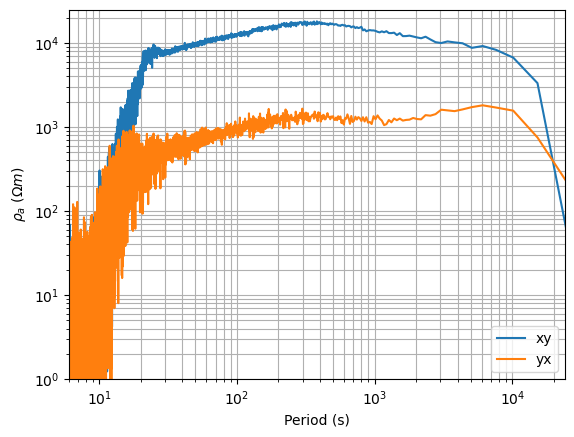

In [86]:
f, Z = mt.calculate_Z(COP_detrend)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy')
plt.loglog(1/f, rho_a[..., 1, 0], label='yx')
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Frequency Banding

The last step that is usually done in MT processing is to average the spectrum within specified frequency bands. For example, all frequencies with periods between 10 and 12 seconds could describe a frequency band. 

In [87]:
period_bands = np.r_[
    np.logspace(np.log10(7), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(20_000), 5)[1:]
]

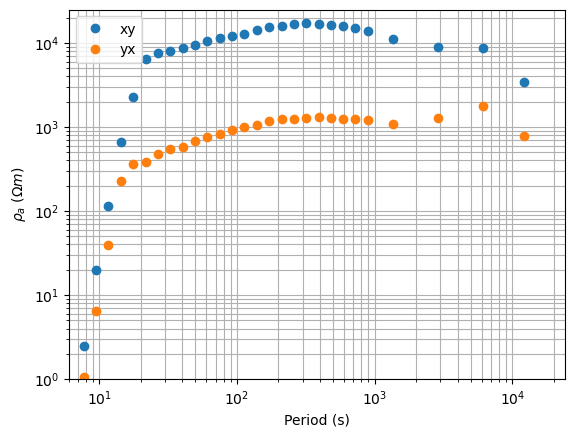

In [88]:
f, Z = mt.calculate_Z(COP_detrend, period_bands=period_bands)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Remote Referencing

As discussed, the cross-correlation functions will be biased if the time-series datasets contain coherent noise relative to each other. Commonly a remote reference site can be used that is far enough away so that the noise is incorherent between the two, but close enough such that the signal is still correlated.

We want to make sure that both dataset time-series cover the same time.

## Carter Lake

In [89]:
coo = mt.MTTimeChannelCollection.from_json("data/Lab5/coo24.json")

In [90]:
period_bands_2 = np.r_[
    np.logspace(np.log10(7), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(24000), 9)[1:]
]

We need to make sure we only look at time-series that are covering the same time-periods, so lets get the overlapping time series for the two stations.

In [91]:
cop_overlap, coo_overlap = mt.get_overlapping_series(cop, coo)

Then lets repeat the above processing steps to each of the sites:

In [96]:
cop_rr = cop_overlap.split(10).detrend().window()
COP_rr = cop_rr.frequency_spectrum().calibrate().orient()

coo_rr = coo_overlap.split(10).detrend().window()
COO_rr = coo_rr.frequency_spectrum().calibrate().orient()

* Now we need to include the remote station when calculating the transfer functions!

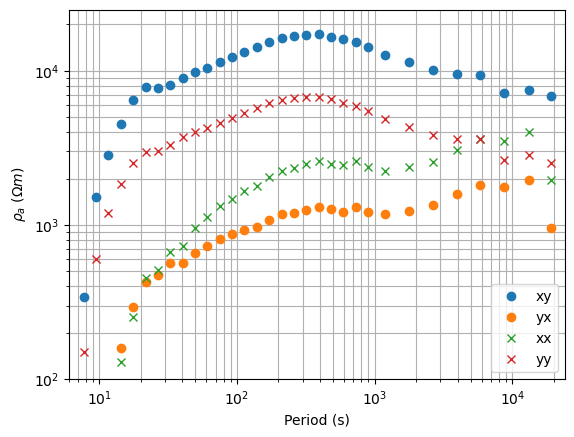

In [97]:
f, Z = mt.calculate_Z(COP_rr, remote=COO_rr, period_bands=period_bands_2)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 0, 0], label='xx', marker='x', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 1], label='yy', marker='x', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([100, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

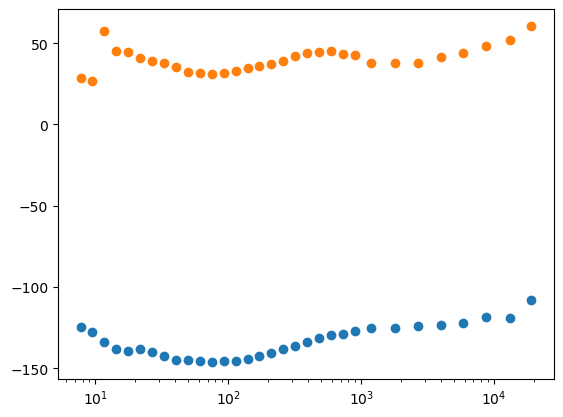

In [98]:
plt.semilogx(1/f, np.angle(Z[..., 0, 1], deg=True), label='xy', marker='o', linestyle="")
plt.semilogx(1/f, np.angle(Z[..., 1, 0], deg=True), label='yx', marker='o', linestyle="")

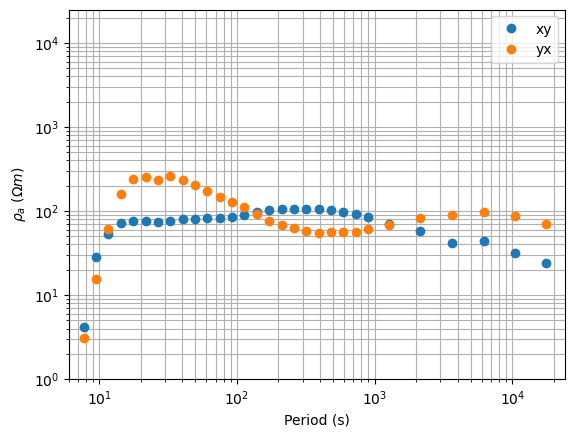

In [31]:
f, Z = mt.calculate_Z(COO_rr, remote=COP_rr, period_bands=period_bands_2)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

### Todo:

* Experiment with adjusting the number of splits

* Experiment with the frequency bands

* Comment on the changes to the calculated data after each operation:

    * Calibration
    * Splitting
    * Detrending
    * Windowing
    * Rotating
    * Frequency Banding
    * Remote Referencing